In [1]:
import torch
import numpy as np
from matplotlib import pyplot as plt

import utilities as utils
import care

# Training the global operator on real-world data

### Stationary real-world dataset

The real-world data include a stationary 440 Hz signal.


inf >> dataset parameters:

 dataset  batches  timeseries length channels
--------  -------  ----------------- --------
   train     3500                200        1
   valid     1000                200        1
    test      500                200        1



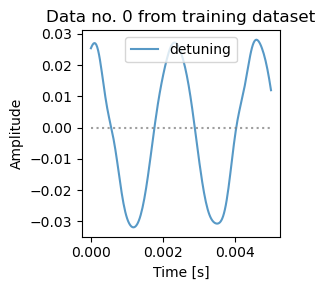

In [2]:
# --!------------------------------------------------------!
# --! display dataset metrics

dataset_dir     = 'data/train_meas_g'
timeseries_len  = 200
timestep        = 2.5e-5
x_dims_n        = 1
x_len           = 200
utils.disp_dataset(dataset_dir, timeseries_len, timestep, data_n=1)

### Model instantiation

As in the synthetic case, the model is instantiated with 4 basis functions: a sine and a cosine, as well as 2 data-driven functions. We also set parameter $\tau=40$ to align with the synthetic example. Of course, as our real-world data feature a single oscillatory mode then the DMD-like global operator will identify only one complex pair of eigenvalues.

In [3]:
# --!--------------------------------------------------------------------------
# --! instantiate a model

# --! ensure reproducible results
seed = 5
torch.manual_seed(seed)

cfg = care.config(

    timeseries_dims_n     = x_dims_n,
    timeseries_sz         = x_len,
    timeseries_timestep   = timestep,

    funs={
        'sin'   : 2,
        'cos'   : 2,
        'data1' : 1,
        'data2' : 1,
    },
    fun_params_kern_sz    = 40,

    fit_weight_lin_global = 1.,
    fit_weight_lin_local  = 0.
)

model = care.detune(cfg)

### Global operator training

In [4]:
# --!--------------------------------------------------------------------------
# --! train the global operator

train_params = {
    'dataset_dir'   : dataset_dir,
    'timeseries_sz' : timeseries_len,
    'train_files_n' : 7,
    'batch_sz'      : 128,
    'epochs_n'      : 100,
    'x_sz'          : x_len,
    'is_verbose'    : True,
    'is_global'     : True,
    'learn_rate'    : 1e-3,
    'weight_decay'  : 1e-8,
    'alpha'         : 1.0
}

outs = utils.train(model, train_params)

loss_train_pred  = outs[0]
loss_train_lin_g = outs[1]
loss_train_lin_l = outs[2]
loss_valid_pred  = outs[3]
loss_valid_lin_g = outs[4]
loss_valid_lin_l = outs[5]

inf >> Number of data files for training : 7
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> processing training file number 4
inf >> processing training file number 5
inf >> processing training file number 6
inf >> processing training file number 7


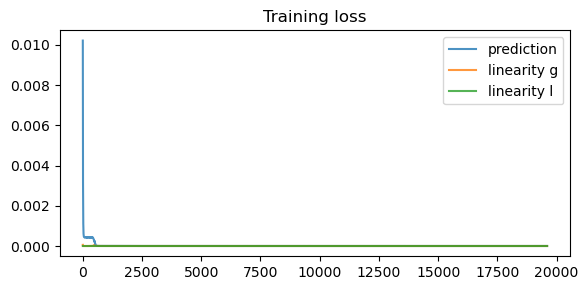

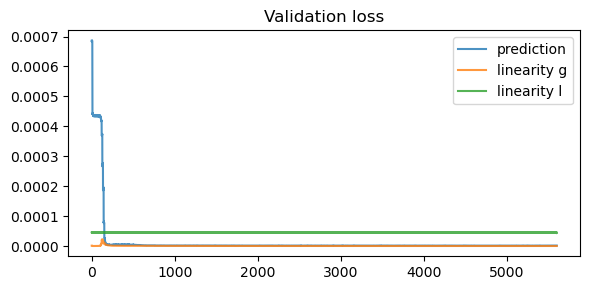

In [5]:
# --!--------------------------------------------------------------------------
# --! display training and validation statistics

with torch.no_grad():
    plt.figure(figsize=(6, 3))
    plt.title('Training loss')
    plt.plot(loss_train_pred, alpha=0.8, label='prediction')
    plt.plot(loss_train_lin_g, alpha=0.8, label='linearity g')
    plt.plot(loss_train_lin_l, alpha=0.8, label='linearity l')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 3))
    plt.title('Validation loss')
    plt.plot(loss_valid_pred, alpha=0.8, label='prediction')
    plt.plot(loss_valid_lin_g, alpha=0.8, label='linearity g')
    plt.plot(loss_valid_lin_l, alpha=0.8, label='linearity l')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [6]:
# --!--------------------------------------------------------------------------
# --! save a trained global model

savemod_on = True
print(model.timeseries_dyn.weight)

if savemod_on:
    torch.save(model, 'models/care_meas_g.pt')

Parameter containing:
tensor([[ 0.5196, -0.2487,  0.1318,  0.2667],
        [ 0.4932, -0.9824, -0.2301,  0.1705],
        [ 1.1929, -0.5135, -0.4042,  0.9664],
        [ 1.7702, -0.6797,  0.0232, -0.4505]], requires_grad=True)


# Training a local operator on real-world data


inf >> dataset parameters:

 dataset  batches  timeseries length channels
--------  -------  ----------------- --------
   train     3500                200        1
   valid     1000                200        1
    test      500                200        1



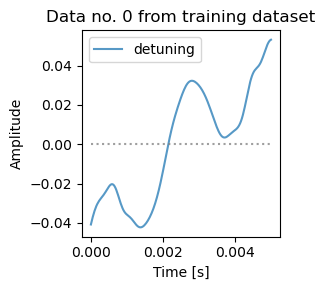

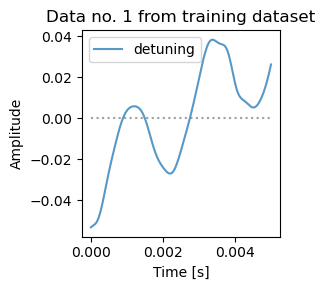

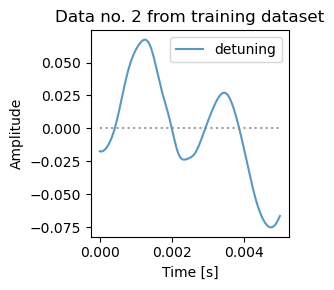

In [7]:
# --!------------------------------------------------------!
# --! display dataset metrics

dataset_dir = 'data/train_meas_l'
utils.disp_dataset(dataset_dir, timeseries_len, timestep)

### Local operator training

In [8]:
# --!--------------------------------------------------------------------------
# --! train the global operator

# --! we reuse the training parameters we defined above, but this time we
# --! update some of them, like the dataset directory, alpha, etc.
train_params['dataset_dir'] = dataset_dir
train_params['is_global']   = False
train_params['alpha']       = 0.25

outs = utils.train(model, train_params)

loss_train_pred  = outs[0]
loss_train_lin_g = outs[1]
loss_train_lin_l = outs[2]
loss_valid_pred  = outs[3]
loss_valid_lin_g = outs[4]
loss_valid_lin_l = outs[5]

inf >> Number of data files for training : 7
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> processing training file number 4
inf >> processing training file number 5
inf >> processing training file number 6
inf >> processing training file number 7


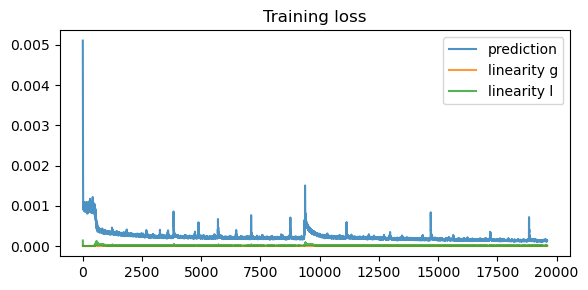

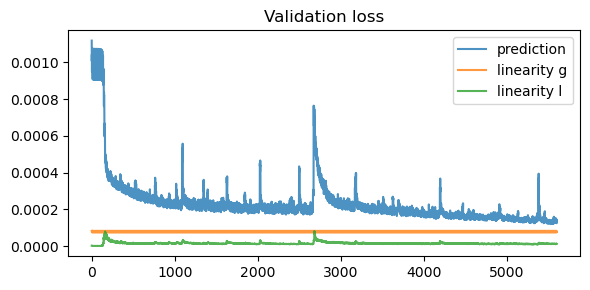

In [9]:
# --! display training statistics
with torch.no_grad():
    plt.figure(figsize=(6, 3))
    plt.title('Training loss')
    plt.plot(loss_train_pred, alpha=0.8, label='prediction')
    plt.plot(loss_train_lin_g, alpha=0.8, label='linearity g')
    plt.plot(loss_train_lin_l, alpha=0.8, label='linearity l')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 3))
    plt.title('Validation loss')
    plt.plot(loss_valid_pred, alpha=0.8, label='prediction')
    plt.plot(loss_valid_lin_g, alpha=0.8, label='linearity g')
    plt.plot(loss_valid_lin_l, alpha=0.8, label='linearity l')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [10]:
# --!--------------------------------------------------------------------------
# --! save a trained local model

savemod_on = True

# --! sanity check that the global operator hasn't changed
print(model.timeseries_dyn.weight)

if savemod_on:
    torch.save(model, 'models/care_meas_l.pt')

Parameter containing:
tensor([[ 0.5196, -0.2487,  0.1318,  0.2667],
        [ 0.4932, -0.9824, -0.2301,  0.1705],
        [ 1.1929, -0.5135, -0.4042,  0.9664],
        [ 1.7702, -0.6797,  0.0232, -0.4505]])
